# Setup

In [1]:
# base
import os
import sys
import gc
import re
import warnings
import logging
import pickle
from time import ctime, time
from datetime import timedelta
from collections import Counter
import itertools
import session_info

sys.path.insert(0, '../..')
logging.basicConfig(level="WARNING")
warnings.simplefilter("ignore", FutureWarning)
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

# data manipulation
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

warnings.simplefilter("ignore", pd.errors.DtypeWarning)
mlogger = logging.getLogger("matplotlib")
mlogger.setLevel(logging.WARNING)

# single cell
import anndata as ad
import scanpy as sc
import squidpy as sq
import liana as li

# custom
from single_cell.R import *
from single_cell.preprocess import *
from single_cell.plot import *
from single_cell.analysis import *
from spatial_seq.plot import *
from utils import *

# R
import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter

# analysis & device specific
CORES = 20
DATADIR = Path("../../../data/processed/single_cell")
REFDIR = Path("../../../references")
MAIN_DIR = DATADIR / "combined"
SUBSETS_DIR = MAIN_DIR / "subsets"
DOUBLETMETHODS = ["scDblFinder", "DoubletFinder", "doubletdetection", "scrublet"]
INT_KEY = "INT_scvi_hvg-Identifier"

%load_ext rpy2.ipython
%matplotlib inline
%load_ext autoreload
converter = get_converter()
mpl.rcdefaults()
gc.collect()

session_info.show()

/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/pyro/ops/stats.py:514: SyntaxWarning: invalid escape sequence '\g'
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:388: SyntaxWarning: invalid escape sequence '\m'
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/leidenalg/VertexPartition.py:761: SyntaxWarning: invalid escape sequence '\m'
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:7: SyntaxWarning: invalid escape sequence '\g'
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/leidenalg/Optimiser.py:305: SyntaxWarning: invalid escape sequence '\s'
/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/phenograph/cluster.py:13: DeprecationWarning: Please import `spmatrix` from the `scipy.sparse` namespace; the `scipy.sparse.base` namespace is deprecated and will be removed in SciPy 2.0.0.
/mnt/DATA/home/ethung/spatial_s

# Load

In [ ]:
annotation = "integrated_Outer"
adata = ad.read_zarr(MAIN_DIR / annotation)
gc.collect()
adata

In [ ]:
celltype_markers_concise = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5"],
    "Smooth Muscle Cell": ["Myocd"],
    "Pericyte": ["Enpep"],
    "Epithelial 1": ["Dcdc2a"],
    "Epithelial 2": ["Erbb4"],
    "Macrophage": ["Adgre1"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d"],
    "NK Cell": ["Klrd1"],
}

celltype_markers_full = {
    "Adipocyte": ["Adipoq"],
    "Fibroblast": ["Pdgfra", "Col1a1"],
    "Mesothlial": ["Wt1"],
    "Endothelial": ["Cdh5", "Cldn5"],
    "Smooth Muscle Cell": ["Myocd", "Myh11"],
    "Pericyte": ["Enpep", "Pdgfrb"],
    "Epithelial": ["Dcdc2a", "Erbb4", "Epcam"],
    "Macrophage": ["Adgre1", "Itgam"],
    "Dendritic Cell": ["Flt3"],
    "Neutrophil": ["Csf3r", "S100a8", "S100a9"],
    "Mast Cell": ["Cpa3"],
    "B Cell": ["Ms4a1"],
    "T Cell": ["Cd3d", "Cd3e"],
    "NK Cell": ["Klrd1", "Ncr1"],
}

markers_list = pd.Series([b for a in celltype_markers_concise for b in celltype_markers_concise[a]])
markers_list[~markers_list.isin(adata.var_names)]

markers = {
    "Fibroblast": ["Pdgfra", "Dcn"],
    "Adipocyte": ["Adipoq", "Plin4", "Retn", "Ucp1"],
    "Uncommitted FBs": ["Dpp4", "Cd55", "Pi16", "Aldh1a3"],
    "Committed FBs": ["Pparg", "Icam1", "Cd36"],
    # "Areg (iWAT)" : ["F3", "Clec11a"],
    "Endothelial": ["Pecam1", "Cdh5"],
    "Lymphatic Endo": ["Prox1", "Lyve1"],
    # "Arterial Endo": ["Hey1", "Gkn3"],
    # "Venous Endo": ["Vcam1", "Ackr1"],
    # "Capillary Endo": ["Rgcc", "Car4"],
    "Mesothelial": ["Msln", "Krt19", "Wt1", "Upk3b"],
    "Pericyte": ["Steap4", "Enpep"],
    "SMC": ["Myocd", "Myh11", "Acta2"],
    "Mono/Macs": ["Adgre1", "Mafb", "Cybb"],
    # "MonoMac subsets": ["Lyve1", "Selenop", "C1qa", "Cd9", "Trem2", "Lpl", "Ccl3", "Cxcl3", "Plac8"],
    "Dendritic cell": ["Flt3"],
    "Mast cell": ["Il1rl1", "Cpa3", "Kit"],
    "Neutrophil": ["Csf3r", "S100a9"],
    "NK cell": ["Klrd1", "Xcl1", "Klrb1c"],
    "T cell": ["Cd3d", "Cd3e", "Skap1"],
    # "T cell subsets" : ["Cd4", "Cd8b1", "Cxcr3", "Ccr7", "Sell", "Klrg1", "Il7", "Foxp3"],
    "B cell": ["Ms4a1", "Igkc", "Cd79a", "Cd79b"],
    "Plasmablast": ["Jchain"],
    "Others": ["Dcdc2a", "Erbb4"],
}

markers_list = pd.Series([b for a in markers for b in markers[a]])
markers_list[~markers_list.isin(adata.var_names)]

Series([], dtype: object)

# Check Integration

In [ ]:
# compare all integrations
r, c = 3, 4
f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
axs = axs.flatten()
int_check = "Dataset"

for i, dr_key in enumerate(
    [
        f"UMAP_INT_{method}{modifier}-{batch}"
        for method in ["scanorama", "harmony", "scvi"]
        for batch in ["Dataset", "Identifier"]
        for modifier in ["_hvg", ""]
    ]
):
    sc.pl.embedding(
        adata,
        basis=dr_key,
        color=int_check,
        alpha=0.8,
        ax=axs[i],
        show=False,
        legend_loc="none" if i < len(axs) - 1 else "right margin",
    )

    if i == len(axs) - 1:
        legend_info = axs[-1].get_legend_handles_labels()
        f, ax = plt.subplots()
        ax.legend(*legend_info)
        ax.axis("off")

        axs[-1].get_legend().remove()

maybe worth looking at harmony HVG id/dataset, and SCVI HVG id/dataset + all gene id

In [ ]:
modifier = "_hvg"
for method in ["harmony", "scvi"]:
    for batch in ["Dataset", "Identifier"]:
        int_key = f"INT_{method}{modifier}-{batch}"

        f = plt.figure(figsize=(9, 12), layout="constrained")
        check_integration(
            adata,
            "Dataset",
            f,
            embeddings=[f"UMAP_{int_key}"],
            nrow=3,
            ncol=3,
        )

modifier = ""
method = "scvi"
batch = "Identifier"
int_key = f"INT_{method}{modifier}-{batch}"

f = plt.figure(figsize=(9, 12), layout="constrained")
check_integration(
    adata,
    "Dataset",
    f,
    embeddings=[f"UMAP_{int_key}"],
    nrow=3,
    ncol=3,
)

In [ ]:
f = plt.figure(figsize=(9, 12), layout="constrained")
check_integration(
    adata,
    "Dataset",
    f,
    embeddings=[f"UMAP_{INT_KEY}"],
    nrow=3,
)

In [ ]:
Filter_GeneGroup(adata, "mito", "mt")
Filter_GeneGroup(adata, "ribo", ("Rps", "Rpl"), True, 10)
plot_violinplot(adata, "Dataset", ["pct_counts_ribo", "pct_counts_mito"])

# Add Metadata

In [ ]:
# Get metadata
start = stopwatch(setting=2)
task_start = stopwatch("Reading Data", start)

adatas = {}
annotation = "cleaned"
study = "Emont2022"
adatas[study] = ad.read_zarr(DATADIR / study / annotation)

annotation = "doublet_cleaned"
study = "So2025"
adatas[study] = sc.read_h5ad(DATADIR / study / "1_preprocessed" / f"{annotation}.h5ad")

for study in [
    "Wang2025",
    "Sarvari2021",
    "GonzalezHurtado2025",
    "Jaitlin2019",
    "Kohda2025",
]:
    annotation = "doublet_cleaned"
    adatas[study] = sc.read_h5ad(DATADIR / study / f"{annotation}.h5ad")

task_start = stopwatch(start=task_start, setting=1)
gc.collect()

In [ ]:
# Match metadata

# find matching ids
ids = {}
for dataset in tqdm(adatas):
    adatas[dataset].obs_names = (
        find_barcodes(adatas[dataset].obs_names)
        + f"-{dataset}-"
        + pd.Series(adatas[dataset].obs["Identifier"].values).astype(str)
    ).str.replace("_", "-")
    ids[dataset] = adatas[dataset].obs_names.tolist()

    assert np.all(adata[adata.obs["Dataset"] == dataset].obs_names.isin(ids[dataset]))
    print(len(adata[adata.obs["Dataset"] == dataset]), len(ids[dataset]))

# add columns
adata.obs["Diet"] = None
adata.obs["Age"] = None
adata.obs["Sex"] = None
adata.obs["Depot"] = None

# prepare to add values
metadata_dict = {
    "So2025": {
        "Diet": "Condition",
        "Depot": "Sample Type",
        "Age": "18 weeks",
        "Sex": "Male",
    },
    "Emont2022": {
        "Diet": "diet__type",  # transform
        "Depot": "fat__type",  # transform
        "Age": "development_stage__ontology_label",
        "Sex": "sex__ontology_label",  # transform
    },
    "Sarvari2021": {
        "Diet": "Condition",
        "Depot": "eWAT",
        "Age": "Age",  # transform
        "Sex": "Male",
    },
    "GonzalezHurtado2025": {
        "Diet": "LFD",
        "Depot": "iWAT",
        "Age": "Age",  # transform
        "Sex": "Gender",  # transform
    },
    "Wang2025": {
        "Diet": "LFD",
        "Depot": "eWAT",
        "Age": "Age",  # transform
        "Sex": "Male",
    },
    "Jaitlin2019": {
        "Diet": "Diet",  # transform
        "Depot": "eWAT",
        "Age": "Age",
        "Sex": "Male",
    },
    "Kohda2025": {
        "Diet": "Diet",  # transform
        "Depot": "Depot",
        "Age": "Age",
        "Sex": "Gender",
    },
}

# make naming consistent
dataset = "Emont2022"
adatas[dataset].obs[metadata_dict[dataset]["Diet"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Diet"]]
    .replace(
        {
            "high fat diet": "HFD",
            "normal chow diet": "LFD",
        }
    )
)
adatas[dataset].obs[metadata_dict[dataset]["Depot"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Depot"]]
    .replace(
        {
            "ING": "iWAT",
            "PG": "eWAT",
        }
    )
)
adatas[dataset].obs[metadata_dict[dataset]["Sex"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Sex"]]
    .replace(
        {
            "female": "Female",
            "male": "Male",
        }
    )
)

dataset = "Sarvari2021"
adatas[dataset].obs[metadata_dict[dataset]["Age"]] = (
    adatas[dataset]
    .obs["Sample"]
    .replace(
        {
            "GSM4878207": "28 weeks",
            "GSM4878208": "28 weeks",
            "GSM4878209": "32 weeks",
            "GSM4878210": "28 weeks",
            "GSM4878211": "28 weeks",
            "GSM4878212": "32 weeks",
        }
    )
)

dataset = "GonzalezHurtado2025"
adatas[dataset].obs[metadata_dict[dataset]["Age"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Age"]]
    .replace(
        {
            "Young": "8 weeks",
            "Old": "88 weeks",
        }
    )
)
adatas[dataset].obs[metadata_dict[dataset]["Sex"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Sex"]]
    .replace(
        {
            "Females": "Female",
            "Males": "Male",
        }
    )
)

dataset = "Wang2025"
adatas[dataset].obs[metadata_dict[dataset]["Age"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Age"]]
    .replace(
        {
            "Young": "6 weeks",
            "YoungCD": "6 weeks",
            "Age": "48 weeks",
            "AgeCD": "48 weeks",
        }
    )
)

dataset = "Jaitlin2019"
adatas[dataset].obs[metadata_dict[dataset]["Diet"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Diet"]]
    .replace(
        {
            "High-fat diet": "HFD",
            "Normal chow": "LFD",
        }
    )
)

dataset = "Kohda2025"
adatas[dataset].obs[metadata_dict[dataset]["Diet"]] = (
    adatas[dataset]
    .obs[metadata_dict[dataset]["Diet"]]
    .replace(
        {
            "high-fat diet": "HFD",
            "standard diet": "LFD",
        }
    )
)


# add values by index
for dataset in adatas:
    print()
    print(dataset)
    print(adatas[dataset].shape)
    matched_idx = adata.obs_names.isin(ids[dataset])
    print(matched_idx.sum())

    for col in metadata_dict[dataset]:
        if metadata_dict[dataset][col] in adatas[dataset].obs.columns:
            print(f"{metadata_dict[dataset][col]} found!")
            adata.obs.loc[matched_idx, col] = adatas[dataset].obs.loc[
                ids[dataset], metadata_dict[dataset][col]
            ]
        else:
            print(
                f"* {metadata_dict[dataset][col]} not found in adatas[{dataset}]! Adding directly."
            )
            adata.obs.loc[matched_idx, col] = metadata_dict[dataset][col]

order_obs(adata, "Diet", ["LFD", "HFD"])
order_obs(adata, "Sex", ["Male", "Female"])
order_obs(adata, "Depot", ["eWAT", "iWAT"])
order_obs(
    adata,
    "Age",
    adata.obs["Age"]
    .str.extract(r"(\d+)")[0]
    .astype(int)
    .astype("category")
    .cat.categories.astype(str)
    + " weeks",
)

# Cluster

In [ ]:
resolutions = np.arange(1, 13) / 10
Cluster(
    adata,
    "global_leiden",
    resolutions=resolutions,
    neighbor_key=f"neighbors_{INT_KEY}",
)

In [ ]:
crosstabs = [
    pd.crosstab(adata.obs[clustering], adata.obs["Dataset"])
    for clustering in adata.obs.loc[:, adata.obs.columns.str.contains("global_leiden")]
]
crosstabs[0]

In [ ]:
r, c = 3, 4
f, axs = plt.subplots(r, c, figsize=(10 * c, 8 * r), layout="constrained")
axs = axs.flatten()

for i, res in enumerate([col for col in adata.obs.columns if "global_leiden" in col]):
    sc.pl.embedding(
        adata,
        basis=f"UMAP_{INT_KEY}",
        color=res,
        palette=create_palette(len(adata.obs[res].unique())),
        ax=axs[i],
        show=False,
    )

In [ ]:
for cell in tqdm(celltype_markers_concise):
    for m in celltype_markers_concise[cell]:
        f = clustree(
            adata,
            [f"global_leiden_{res}" for res in [0.3, 0.6, 0.9, 1.2]] + ["celltypist"],
            title=cell,
            edge_weight_threshold=0.05,  # node_size_range=(250,2500),
            node_color_gene=m,
            node_color_gene_use_raw=False,
            node_colormap="Reds",
            show_colorbar=True,
            x_spacing=8,
            y_spacing=0.3,
        )

# Annotation

In [ ]:
# prep full data
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers["celltypist_norm"] = adata.X.copy()

#### So et al 2025

In [ ]:
ref_name = "So2025"
new_col = f"celltype_{ref_name}"

folder = DATADIR / ref_name / "5_analysis"
adata_ref = sc.read_h5ad(folder / f"annotated-slim.h5ad")
adata_ref.obs_names = (
    find_barcodes(adata_ref.obs_names)
    + "-"
    + ref_name
    + "-"
    + pd.Series(list(adata_ref.obs["Identifier"].astype(str)))
).str.replace("_", "-")

adata.obs[new_col] = None
adata.obs[new_col].update(adata_ref.obs["cell_type"])
adata.obs[new_col] = adata.obs[new_col].astype(str).astype("category")

f, ax = plt.subplots(1, 1, figsize=(10, 6))
adata.obs["tmp_column"] = adata.obs[new_col].replace({"None": None})
sc.pl.embedding(
    adata,
    basis=f"UMAP_{INT_KEY}",
    color="tmp_column",
    palette=create_palette(len(adata.obs[new_col].astype("category").unique())),
    # na_color="white",
    ax=ax,
    show=False,
)
adata.obs = adata.obs.drop(columns=["tmp_column"])

In [ ]:
TRAIN = False
DOWNSAMPLE = True
model_save_location = DATADIR / ref_name / "celltypist_model.pkl"
reference_col = "cell_type"

if TRAIN is True:
    # prep reference data
    adata_ref.X = adata_ref.layers["counts"].copy()
    sc.pp.normalize_total(adata_ref, target_sum=1e4)
    sc.pp.log1p(adata_ref)

    # generate celltypist model
    if DOWNSAMPLE is True:
        sampled_cell_index = celltypist.samples.downsample_adata(
            adata_ref, mode="each", n_cells=500, by=reference_col, return_index=True
        )
        model = celltypist.train(
            adata_ref[sampled_cell_index], reference_col, n_jobs=10, use_SGD=True
        )
    else:
        model = celltypist.train(adata_ref, reference_col, n_jobs=10, use_SGD=True)
    model.write(model_save_location)

else:
    adata.X = adata.layers["celltypist_norm"].copy()

sc.pp.pca(adata)
predictions = celltypist.annotate(
    adata, model=str(model_save_location), majority_voting=True
)
del adata.obsm["X_pca"], adata.uns["pca"], adata.varm["PCs"]

celltypist.dotplot(
    predictions,
    use_as_reference=new_col,
    use_as_prediction="predicted_labels",
    title=f"celltypist {ref_name} (standard)",
)
celltypist.dotplot(
    predictions,
    use_as_reference=new_col,
    use_as_prediction="majority_voting",
    title=f"celltypist {ref_name} (with overcluster & voting)",
)
adata = predictions.to_adata()

In [ ]:
# plot counts
r, c = 2, 1
f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
axs = axs.flatten()
for i, col in enumerate(["predicted_labels", "majority_voting"]):
    sc.pl.embedding(
        adata,
        basis=f"UMAP_{INT_KEY}",
        color=col,
        palette=color_gen(adata.obs[col].cat.categories),
        show=False,
        ax=axs[i],
    )

    # add legend label counts
    for label in axs[i].get_legend().get_texts():
        clust = label.get_text()
        label.set_text(clust + f" ({Counter(adata.obs[col])[clust]})")

In [ ]:
ordered_cats = [
    "Adipocyte",
    "Fibroblast",
    "Mesothelial",
    "Endothelial",
    "PC/SMC",
    "Macrophage",
    "Dendritic Cell",
    "Mast Cell",
    "T Cell",
    "B Cell",
]
key = "celltypist_So2025"
adata.obs[key] = pd.Categorical(
    adata.obs["predicted_labels"], categories=ordered_cats, ordered=True
)
order_obs(adata, "celltype_So2025", ordered_cats)

# for col in ["Dataset", "Identifier", "Diet", "Age", "Sex", "Depot"]:
#     plt.figure(figsize=(8, 5))
#     sns.heatmap(
#         pd.crosstab(adata.obs[col], adata.obs[key], normalize="index").T, cmap="Reds"
#     )

clear_adata(
    adata, ["predicted_labels", "majority_voting", "conf_score", "over_clustering"]
)

#### Emont et al 2022

In [ ]:
ref_name = "Emont2022"
new_col = f"celltype_{ref_name}"

folder = DATADIR / ref_name
adata_ref = ad.read_zarr(folder / "cleaned")
adata_ref.obs_names = (
    find_barcodes(adata_ref.obs_names)
    + "-"
    + ref_name
    + "-"
    + pd.Series(list(adata_ref.obs["Identifier"].astype(str)))
).str.replace("_", "-")

adata.obs[new_col] = None
adata.obs[new_col].update(adata_ref.obs["cell_type__custom"])
adata.obs[new_col] = adata.obs[new_col].astype(str).astype("category")

f, ax = plt.subplots(1, 1, figsize=(10, 6))
adata.obs["tmp_column"] = adata.obs[new_col].replace({"None": None})
sc.pl.embedding(
    adata,
    basis=f"UMAP_{INT_KEY}",
    color="tmp_column",
    palette=create_palette(len(adata.obs[new_col].astype("category").unique())),
    # na_color="white",
    ax=ax,
    show=False,
)
adata.obs = adata.obs.drop(columns=["tmp_column"])

In [ ]:
TRAIN = False
DOWNSAMPLE = True
model_save_location = DATADIR / ref_name / "celltypist_model.pkl"
reference_col = "cell_type__custom"

if TRAIN is True:
    # prep reference data
    adata_ref.X = adata_ref.layers["counts"].copy()
    sc.pp.normalize_total(adata_ref, target_sum=1e4)
    sc.pp.log1p(adata_ref)

    adata.X = adata.layers["counts"].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    adata.layers["celltypist_norm"] = adata.X.copy()

    # generate celltypist model
    if DOWNSAMPLE is True:
        sampled_cell_index = celltypist.samples.downsample_adata(
            adata_ref, mode="each", n_cells=200, by=reference_col, return_index=True
        )
        model = celltypist.train(
            adata_ref[sampled_cell_index], reference_col, n_jobs=10, use_SGD=True
        )
    else:
        model = celltypist.train(adata_ref, reference_col, n_jobs=10, use_SGD=True)
    model.write(model_save_location)

else:
    adata.X = adata.layers["celltypist_norm"].copy()

sc.pp.pca(adata)
predictions = celltypist.annotate(
    adata, model=str(model_save_location), majority_voting=True
)
del adata.obsm["X_pca"], adata.uns["pca"], adata.varm["PCs"]

celltypist.dotplot(
    predictions,
    use_as_reference=new_col,
    use_as_prediction="predicted_labels",
    title=f"celltypist {ref_name} (standard)",
)
celltypist.dotplot(
    predictions,
    use_as_reference=new_col,
    use_as_prediction="majority_voting",
    title=f"celltypist {ref_name} (with overcluster & voting)",
)
adata = predictions.to_adata()

In [ ]:
# plot counts
r, c = 2, 1
f, axs = plt.subplots(r, c, figsize=(10 * c, 6 * r), layout="constrained")
axs = axs.flatten()
for i, col in enumerate(["predicted_labels", "majority_voting"]):
    sc.pl.embedding(
        adata,
        basis=f"UMAP_{INT_KEY}",
        color=col,
        palette=color_gen(adata.obs[col].cat.categories),
        show=False,
        ax=axs[i],
    )

    # add legend label counts
    for label in axs[i].get_legend().get_texts():
        clust = label.get_text()
        label.set_text(clust + f" ({Counter(adata.obs[col])[clust]})")

In [ ]:
ordered_cats = [
    "ASPC",
    "adipocyte",
    "mesothelium",
    "endothelial",
    "LEC",
    "SMC",
    "pericyte",
    "male_epithelial",
    "female_epithelial",
    "macrophage",
    "monocyte",
    "dendritic_cell",
    "mast_cell",
    "neutrophil",
    "b_cell",
    "t_cell",
    "nk_cell",
]
key = "celltypist_Emont2022"
adata.obs[key] = pd.Categorical(
    adata.obs["predicted_labels"], categories=ordered_cats, ordered=True
)
order_obs(adata, "celltype_Emont2022", ordered_cats)

for col in ["Dataset", "Identifier", "Diet", "Age", "Sex", "Depot"]:
    plt.figure()
    sns.heatmap(
        pd.crosstab(adata.obs[col], adata.obs[key], normalize="index").T, cmap="Reds"
    )

clear_adata(
    adata, ["predicted_labels", "majority_voting", "conf_score", "over_clustering"]
)

# Markers Check

In [ ]:
plot_violinplot(adata, "celltypist_So2025", celltype_markers_concise, bracket_fontsize=10)
plot_violinplot(adata, "celltypist_Emont2022", celltype_markers_concise, bracket_fontsize=10)

In [ ]:
# plot final celltype on each integration
c, r = 4, 3
f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
axs = axs.flatten()
key = "celltype"
palette = create_palette(len(adata.obs[key].unique()))

for i, dr_key in enumerate(
    tqdm(
        [
            f"UMAP_INT_{method}{modifier}-{batch}"
            for method in ["scanorama", "harmony", "scvi"]
            for batch in ["Dataset", "Identifier"]
            for modifier in ["_hvg", ""]
        ]
    )
):
    sc.pl.embedding(
        adata,
        basis=dr_key,
        color=key,
        palette=palette,
        show=False,
        ax=axs[i],
        size=7,
        legend_loc="none",
    )

c, r = 4, 3
f, axs = plt.subplots(r, c, figsize=(8 * c, 6 * r), layout="constrained")
axs = axs.flatten()

for i, dr_key in enumerate(
    tqdm(
        [
            f"LocalMAP_INT_{method}{modifier}-{batch}"
            for method in ["scanorama", "harmony", "scvi"]
            for batch in ["Dataset", "Identifier"]
            for modifier in ["_hvg", ""]
        ]
    )
):
    sc.pl.embedding(
        adata,
        basis=dr_key,
        color=key,
        palette=palette,
        show=False,
        ax=axs[i],
        size=7,
        legend_loc="none" if i < len(axs) - 1 else "right margin",
    )

    if i == len(axs) - 1:
        legend_info = axs[-1].get_legend_handles_labels()
        axs[-1].get_legend().remove()

        f, ax = plt.subplots()
        ax.legend(*legend_info)
        ax.axis("off")

In [ ]:
# plots violins by leiden
for clustering in [col for col in adata.obs.columns if "global_leiden" in col]:
    plot_violinplot(adata, clustering, markers, useStripPlot=False, title=clustering)

In [ ]:
# finalize celltype assignments
emont_mapping = {
    "adipocyte": "Adipocyte",
    "ASPC": "Fibroblast",
    "mesothelium": "Mesothelial",
    "endothelial": "Endothelial",
    "LEC": "Endothelial",
    "SMC": "Smooth Muscle",
    "pericyte": "Pericyte",
    "male_epithelial": "Epithelial",
    "female_epithelial": "Epithelial",
    "macrophage": "Macrophage",
    "monocyte": "Macrophage",
    "dendritic_cell": "Dendritic",
    "mast_cell": "Mast Cell",
    "neutrophil": "Neutrophil",
    "b_cell": "B Cell",
    "t_cell": "T Cell",
    "nk_cell": "NK Cell",
}

adata.obs["celltype"] = adata.obs["celltypist_Emont2022"].map(emont_mapping)

order_obs(adata, "celltype", pd.Series(emont_mapping.values()).unique())

f, ax = plt.subplots(1, 1, figsize=(8, 5), layout="constrained")
sc.pl.embedding(
    adata,
    basis=f"UMAP_{INT_KEY}",
    color="celltype",
    palette=create_palette(len(adata.obs["celltype"].unique())),
    show=False,
    ax=ax,
    size=5,
)
ax.annotate(
    f"n = {adata.shape[0]}",
    size=10,
    fontweight="bold",
    xy=(0.98, 0.02),
    xycoords="axes fraction",
    horizontalalignment="right",
    verticalalignment="bottom",
)

Palette not found! Generating palette.


Plotting violins:   0%|          | 0/25 [00:00<?, ?it/s]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:965: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

Plotting violins:   4%|▍         | 1/25 [00:03<01:34,  3.93s/it]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:965: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

Plotting violins:   8%|▊         | 2/25 [00:07<01:26,  3.75s/it]/mnt/DATA/home/ethung/spatial_seq/.venv/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:965: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and se

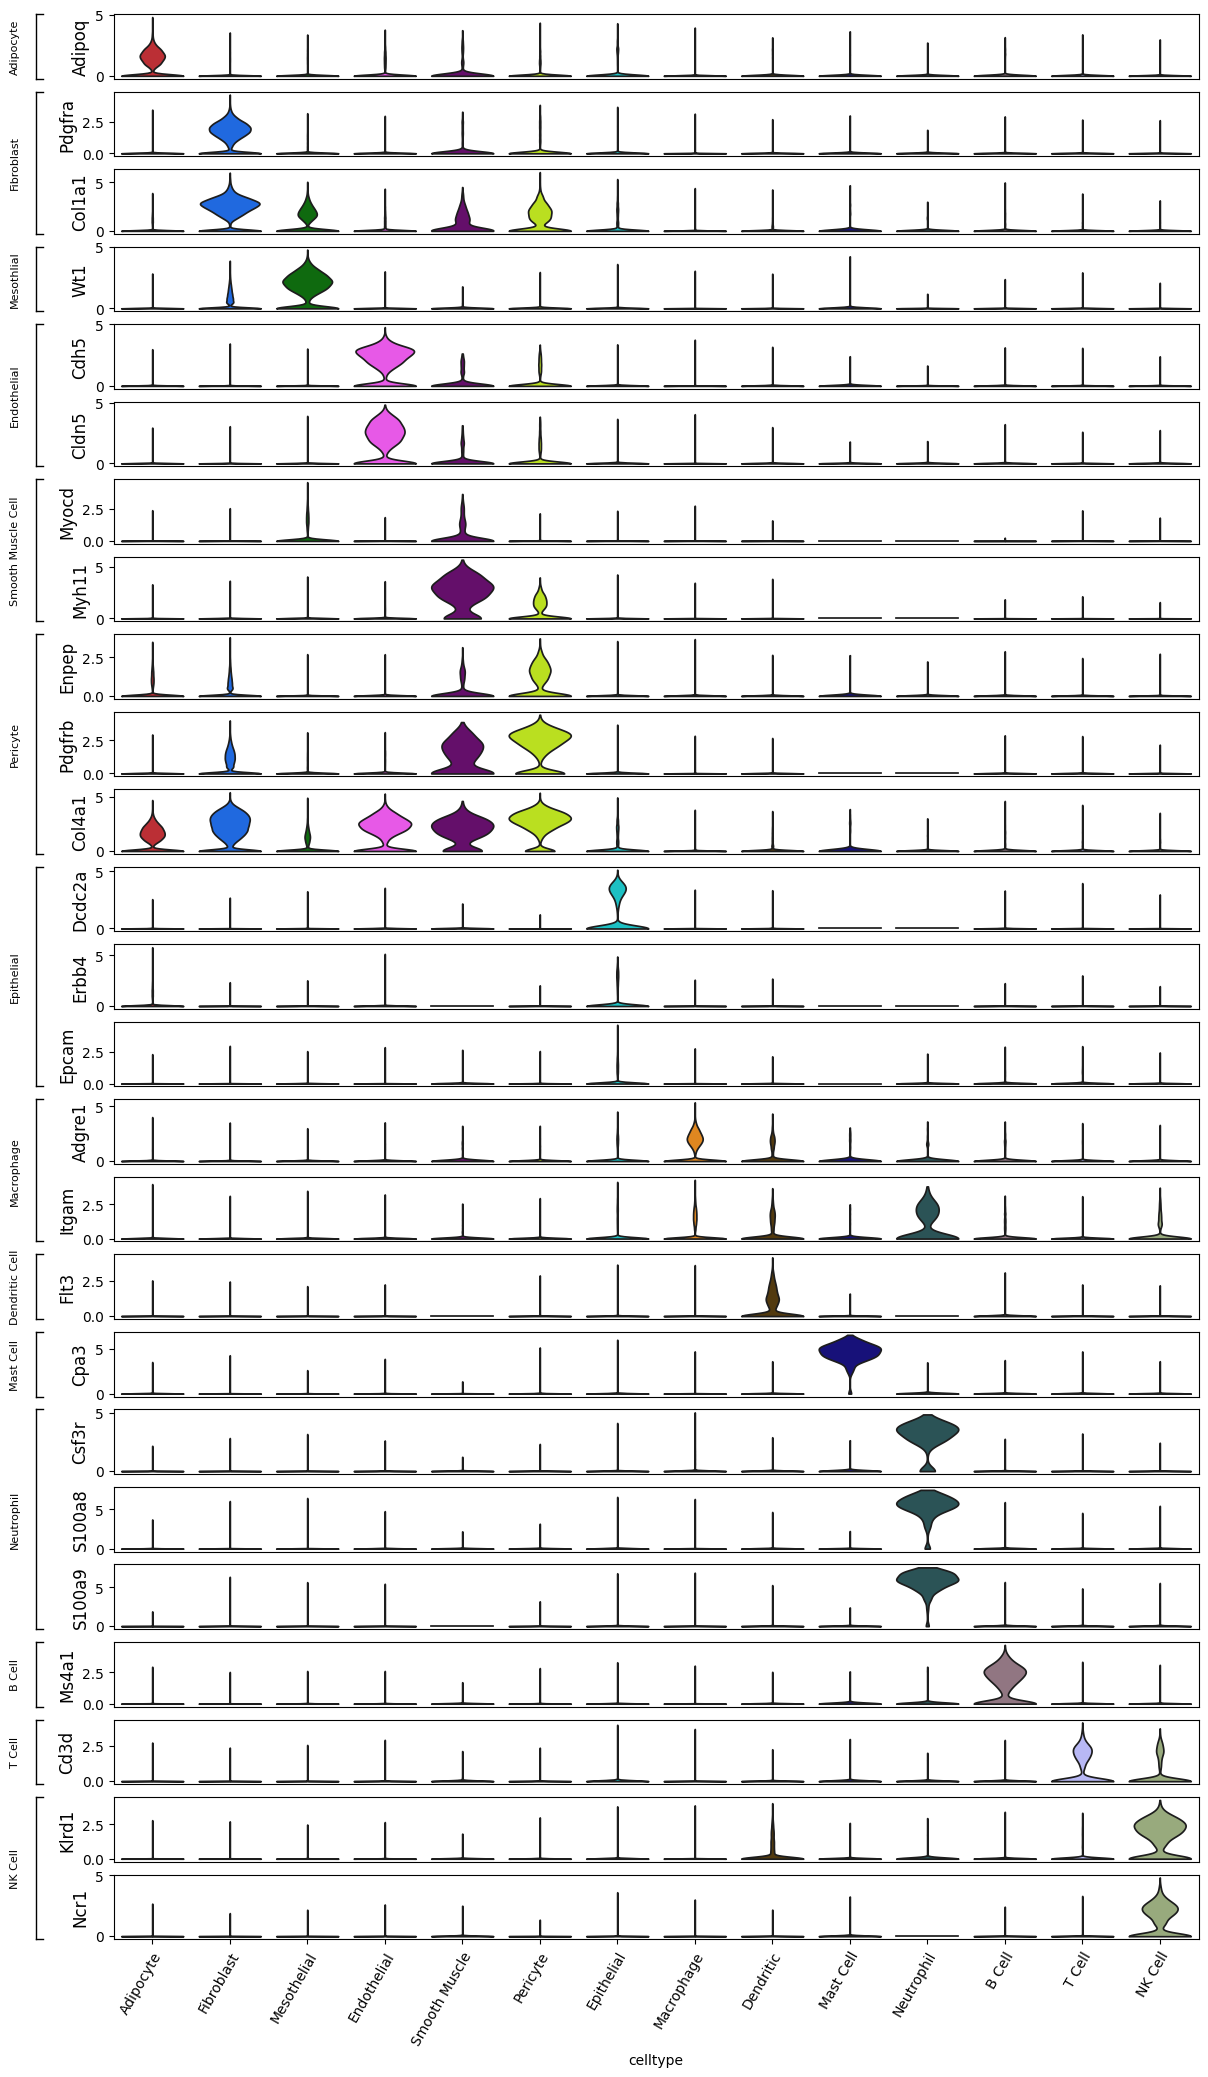

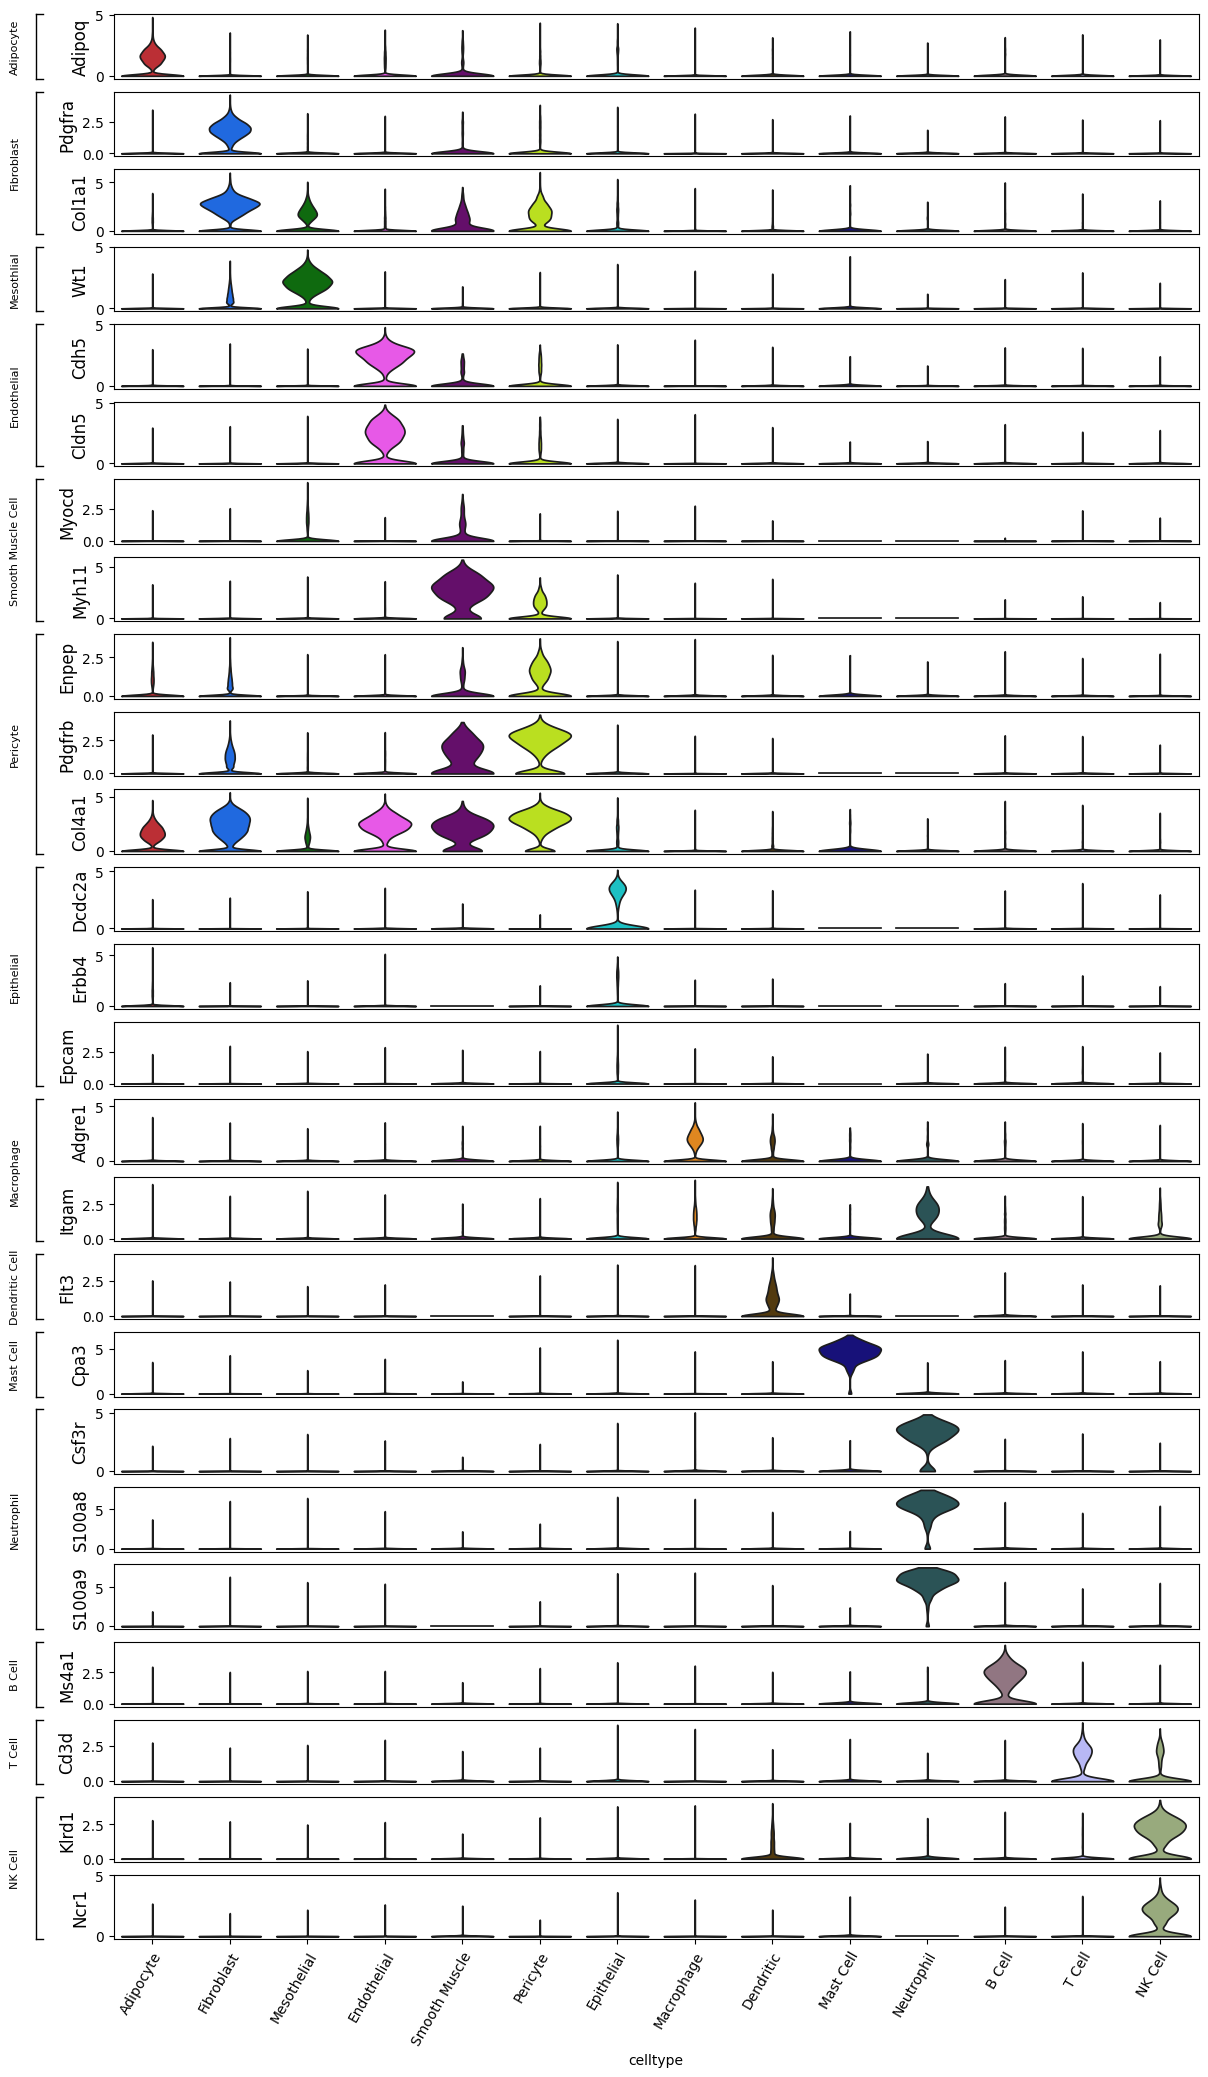

In [4]:
plot_violinplot(adata, "celltype", celltype_markers_full, bracket_fontsize=8)

In [ ]:
plot_violinplot(adata, "global_leiden_0.6", celltype_markers_concise, bracket_fontsize=8)

# DEGs

In [ ]:
adata
sc.tl.rank_genes_groups(adata, groupby="celltypist")
sc.pl.rank_genes_groups(adata)

# Save

In [ ]:
clear_adata(adata, ["dendrogram", "colors"])
# adata.write_zarr(DATADIR / "combined" / "All_Data")
adata.write(DATADIR / "combined" / "All_Data.h5ad")
gc.collect()

In [2]:
adata = sc.read_h5ad(MAIN_DIR / "eWAT_Male.h5ad")
gc.collect()
adata

AnnData object with n_obs × n_vars = 191104 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_

In [ ]:
# adata = ad.read_zarr(DATADIR / "combined" / "All_Data")
adata = sc.read_h5ad(DATADIR / "combined" / "All_Data.h5ad")
gc.collect()
adata

# Create Male eWAT specific object

In [ ]:
adata.obs["cloupe_barcode"] = adata.obs_names.str.replace("-", "_")
to_replace = adata.obs["cloupe_barcode"][
    adata.obs["Dataset"].isin(["Jaitlin2019", "Kohda2025"])
]
new_barcodes = generate_barcodes(len(to_replace), version="3M-february-2018_TRU.txt.gz")
adata.obs.loc[to_replace.index, "cloupe_barcode"] = list(
    pd.Series(new_barcodes) + to_replace.str.replace(r"[ATCG]{16}", "", regex=True)[0]
)
v, nv = validate_barcodes(
    find_barcodes(adata.obs["cloupe_barcode"]), version="3M-february-2018_TRU.txt.gz"
)

In [ ]:
adata = adata[~(adata.obs["Sex"].isin(["Female"]))]
adata = adata[~(adata.obs["Depot"].isin(["iWAT"]))]

f = plt.figure(figsize=(18, 12), layout="constrained")
check_integration(
    adata,
    "Dataset",
    f,
    embeddings=[f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"],
    nrow=2,
    ncol=2,
)

f = plt.figure(figsize=(18, 9), layout="constrained")
check_integration(
    adata,
    "Diet",
    f,
    embeddings=[f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"],
    nrow=1,
    ncol=2,
)

f = plt.figure(figsize=(18, 15), layout="constrained")
check_integration(
    adata,
    "Age",
    f,
    embeddings=[f"UMAP_{INT_KEY}", f"LocalMAP_{INT_KEY}"],
    nrow=3,
    ncol=2,
)
adata.write(MAIN_DIR / "eWAT_Male.h5ad")

In [2]:
adata = sc.read_h5ad(MAIN_DIR / "eWAT_Male.h5ad")

AnnData object with n_obs × n_vars = 191104 × 36044
    obs: 'Identifier', 'Dataset', 'n_genes', 'n_counts', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'Diet', 'Age', 'Sex', 'Depot', 'global_leiden_0.1', 'global_leiden_0.2', 'global_leiden_0.3', 'global_leiden_0.4', 'global_leiden_0.5', 'global_leiden_0.6', 'global_leiden_0.7', 'global_leiden_0.8', 'global_leiden_0.9', 'global_leiden_1.0', 'global_leiden_1.1', 'global_leiden_1.2', 'celltype_So2025', 'celltypist_So2025', 'celltype_Emont2022', 'celltypist_Emont2022', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'celltype', 'cloupe_barcode', 'total_counts_unknown', 'log1p_total_counts_unknown', 'pct_counts_unknown'
    var: 'n_cells', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'highly_

# Sandbox

In [ ]:
sc.pp.neighbors(adata, use_rep=f"LocalMAP_{INT_KEY}", key_added=f"neighbors_LocalMAP_{INT_KEY}")

In [ ]:
# # update object
# adata = sc.read_h5ad(MAIN_DIR / "eWAT_Male.h5ad")

# del adata.obsm["UMAP"]
# rename_obsm(adata, "", prefix="global_")
# rename_obsm(adata, "Dataset", replace="all-Dataset", filter="hvg")
# rename_obsm(adata, "Identifier", replace="all-Identifier", filter="hvg")
# rename_obsm(adata, "_hvg", replace="-hvg")
# rename_obsm(adata, "PCA", replace="PCA-all", filter="hvg")
# rename_obsm(adata, "none", replace="none-all", filter="hvg")

# del adata.obsp["connectivities"], adata.obsp["distances"]
# rename_obsp(adata, "neighbors_", replace="neighbors_global_")
# rename_obsp(adata, "_hvg", replace="-hvg")
# rename_obsp(adata, "Dataset", replace="all-Dataset", filter="hvg")
# rename_obsp(adata, "Identifier", replace="all-Identifier", filter="hvg")
# rename_obsp(adata, "none", replace="none-all", filter="hvg")

# # clear_uns(adata, "INT", filter="neighbor")
# rename_uns(adata, "neighbors_", replace="neighbors_global_")
# rename_uns(adata, "_hvg", replace="-hvg")
# rename_uns(adata, "Dataset", replace="all-Dataset", filter="hvg")
# rename_uns(adata, "Identifier", replace="all-Identifier", filter="hvg")
# rename_uns(adata, "PCA", replace="PCA-all", filter="hvg")
# rename_uns(adata, "none", replace="none-all", filter="hvg")

# for key in list(adata.uns):
#     if "neighbors" in key:
#         for var in ["connectivities", "distances"]:
#             adata.uns[key][f'{var}_key'] = f"{key}_{var}"

# rename_varm(adata, "_hvg", replace="-hvg")
# rename_varm(adata, "PCA", replace="PCA-all", filter="hvg")

# Filter_GeneGroup(adata, "unknown", "^ENMUSG|^Gm[0-9]|Rik")

# adata.write(MAIN_DIR / "eWAT_Male.h5ad")
# adata.write_zarr(MAIN_DIR / "eWAT_Male.zarr")

# adata

In [ ]:
adata_new = sc.AnnData(
    X=adata.layers["counts"].copy(),
    obs=adata.obs[["Dataset", "Identifier", "Diet", "Age", "Sex", "Depot", "celltype"]],
    var=adata.var.drop(columns=adata.var.columns, inplace=False),
)
adata_new.X = scipy.sparse.csc_array(adata_new.X)
adata_new.write_h5ad(MAIN_DIR / "eWAT_Male_SLIM.h5ad")

In [ ]:
subset = sketch_downsample(adata, "global_PCA-hvg", N=20000)
subset = sc.AnnData(
    X=subset.to_df(),
    obs=subset.obs[
        ["Dataset", "Identifier", "Diet", "Age", "Sex", "Depot", "celltype"]
    ],
)
subset.write_h5ad(MAIN_DIR / "geosketch_20000.h5ad")

subset = sketch_downsample(adata, "global_PCA-hvg", N=2500)
subset = sc.AnnData(
    X=subset.to_df(),
    obs=subset.obs[
        ["Dataset", "Identifier", "Diet", "Age", "Sex", "Depot", "celltype"]
    ],
)
subset.write_h5ad(MAIN_DIR / "geosketch_2500.h5ad")